# NYC Restaurant Project – Full Report with All Code and Answers

## Motivation


**What is your dataset?**

This project brings together two rich datasets to better understand how diners in New York City can make informed decisions about where to eat. The first dataset comes from the NYC Health Department, which conducts detailed inspections of restaurants and assigns scores and grades based on hygiene and safety standards. The second dataset is drawn from TripAdvisor, providing customer reviews and ratings of dining experiences across the city.

**Why did you choose this/these particular dataset(s)?**

We chose these datasets because they offer two different but important perspectives: the objective regulatory view from health inspections, and the subjective experiences of customers. While each dataset on its own is informative, combining them gives a much more complete picture. This is especially valuable for tourists who might be unfamiliar with the city's inspection system and are overwhelmed by the sheer number of dining options—over 28,000, according to estimates.

**What was your goal for the end user's experience?**

Our goal was to create a guide that doesn't just tell readers where to eat based on popularity or cuisine but also helps them understand the health standards behind those places. By integrating inspection grades with customer reviews, we provide a more nuanced way to evaluate restaurants.

---

## Basic stats

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import calplot
import numpy as np
import seaborn as sns
from matplotlib import rc
import re
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import ColumnDataSource, ColorBar, LinearColorMapper, HoverTool, Select, CustomJS, WMTSTileSource
from bokeh.layouts import column, row
from bokeh.palettes import RdYlGn11


# ----------- Data import and cleaning ----------- #

data_health = pd.read_csv('NY_restaurants.csv')
data_review = pd.read_csv('New_York_reviews.csv')

# Normalize the names
def normalize_name(name):
    if pd.isnull(name):
        return ''
    name = name.replace('_', ' ')
    name = re.sub(r'[^a-zA-Z0-9\s]', '', name)
    name = name.lower().strip()
    name = re.sub(r'\s+', ' ', name)
    name = ' '.join(word.capitalize() for word in name.split())
    return name

# Define scoring system
def score_to_grade(score):
    if score <= 13:
        return 'A'
    elif score <= 27:
        return 'B'
    else:
        return 'C'

# Health preprocessing
def prepare_health_data(data):
    # Clean data and sort after date
    data_clean = {'Date': data['INSPECTION DATE'], 
                  'Camis': data['CAMIS'],
                  'Restaurant': data['DBA'],
                  'Boro': data['BORO'],
                  'Violation Code': data['VIOLATION CODE'], 
                  'Latitude': data['Latitude'],
                  'Longitude': data['Longitude'],
                  'Violation Description': data['VIOLATION DESCRIPTION'],
                  'Score': data['SCORE'],
                  'Grade': data['GRADE'],
                  'Cuisine Description': data['CUISINE DESCRIPTION']}
    data_clean = pd.DataFrame(data_clean)

    data_clean.sort_values('Date', ascending=True, inplace=True)
    data_clean['Date'] = pd.to_datetime(data_clean['Date'])

    data = data_clean
    data = data[(data["Latitude"] != 0) & (data["Longitude"] != 0)]
    data = data[data['Date'] < '2025-01-01']
    data = data[data['Date'] > '2021-12-31']
    data['Year'] = data['Date'].dt.year
    data['Month'] = data['Date'].dt.month
    data = data[pd.notna(data['Latitude'])]
    data = data[pd.notna(data['Longitude'])]

    data['Grade'] = data['Score'].apply(score_to_grade)
    data['Restaurant'] = data['Restaurant'].apply(normalize_name)
    data['Score'] = pd.to_numeric(data['Score'], errors='coerce')
    data = data.dropna(subset=['Score'])
    data = data[data['Restaurant'] != '']

    # Drop duplicates of grades per inspection
    data_grade = data.drop_duplicates(subset=['Camis', 'Date'], keep='first')
    data_grade = data_grade[['Camis', 'Date', 'Restaurant', 'Boro', 'Latitude', 'Longitude', 'Score', 'Grade', 'Cuisine Description', 'Month']]

    return data, data_grade


# Review preprocessing
def preprocess_reviews(data):
    data_review_clean = {'Date': data['date'],
                         'Restaurant': data['restaurant_name'],
                         'Restaurant rating': data['rating_review']}
    data_review_clean['Date'] = pd.to_datetime(data_review_clean['Date'], errors='coerce')
    data_review_clean = pd.DataFrame(data_review_clean)
    data_review_clean['Restaurant'] = data_review_clean['Restaurant'].apply(normalize_name)
    data_review_clean['Restaurant rating'] = pd.to_numeric(data_review_clean['Restaurant rating'], errors='coerce')
    data_review_clean['Date'] = pd.to_datetime(data_review_clean['Date'], errors='coerce')
    data_review_clean = data_review_clean.dropna(subset=['Restaurant rating'])
    data_review_clean['Month'] = data_review_clean['Date'].dt.month
    return data_review_clean


In [2]:
#----------- Preprocessing functions ----------- #
# Merging function with shared ratings for chain restaurants and missing ratings as "Not rated"
def merged_datasets(health_data, review_data):
    # Normalize restaurant names
    health_data['Restaurant'] = health_data['Restaurant'].apply(normalize_name)
    review_data['Restaurant'] = review_data['Restaurant'].apply(normalize_name)

    # Aggregate health data
    health_summary = health_data.groupby(['Restaurant', 'Boro']).agg({
        'Camis': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
        'Score': 'mean',
        'Cuisine Description': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown',
        'Latitude': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
        'Longitude': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    }).reset_index()
    health_summary['Grade'] = health_summary['Score'].apply(score_to_grade)

    # Aggregate review data
    review_summary = review_data.groupby('Restaurant')['Restaurant rating'].mean().reset_index()
    review_summary.rename(columns={'Restaurant rating': 'avg_rating'}, inplace=True)

    # Merge health and review data
    merged = pd.merge(health_summary, review_summary, on='Restaurant', how='left')

    # Fill missing ratings with "Not rated"
    merged['avg_rating'] = merged['avg_rating'].fillna("Not rated")

    return merged


In [3]:
# -------------- Apply the preprocessing definitions -------------- #
data_health, data_grade = prepare_health_data(data_health)
data_review = preprocess_reviews(data_review)
merged_data= merged_datasets(data_grade, data_review)

### NYC Health Inspection Data

The dataset is the official inspection dataset from the NYC Health Department, which initially contained 27 columns[2]. We selected the following subset of columns that were most relevant to our analysis:
- **INSPECTION DATE** – The date of the health inspection (converted to datetime format)  
- **CAMIS** – A unique identifier for each restaurant  
- **DBA** – The restaurant's name  
- **BORO** – The borough where the restaurant is located  
- **VIOLATION CODE** – Code for the type of violation  
- **VIOLATION DESCRIPTION** – Description of the health violation  
- **SCORE** – A numerical score assigned during inspection  
- **GRADE** – The official letter grade (A/B/C) assigned based on the score  
- **CUISINE DESCRIPTION** – Type of cuisine  
- **Latitude** and **Longitude** – Geolocation coordinates


We filtered out entries with missing or invalid coordinates and restricted the dataset to inspections from the full calendar years 2022 to 2024 to ensure relevance. Dates were properly parsed, and duplicate inspections per restaurant per day were removed. 
Two cleaned datasets were extracted from the inspection data.

- **data_grade**: Focused on the inspection grade per restaurant per inspection, saved as data_grade. This dataset is used when the individual health grades from all inspections of a specific restaurant are relevant.

- **data_health**: Focused on how many violations each restaurant received and which types they were, saved as data_health. This dataset is used when the quantity and nature of violations are important—not just the inspection score or grade.

The first few rows of both dataset is shown below for an easy overview



In [4]:
data_grade.head()

,Camis,Date,Restaurant,Boro,Latitude,Longitude,Score,Grade,Cuisine Description,Month
250967,50134635,2024-01-02,Dawei,Queens,40.759110,-73.834161,34.0,C,Chinese,1
142097,50124853,2024-01-02,Prawnaholic,Manhattan,40.760367,-73.981533,50.0,C,Asian/Asian Fusion,1
133046,50070414,2024-01-02,Sonora,Brooklyn,40.682411,-73.919911,46.0,C,Mexican,1
144402,50006310,2024-01-02,Claw Daddys,Manhattan,40.721983,-73.988253,56.0,C,Seafood,1
274786,50044930,2024-01-02,Cafe Delectica,Manhattan,40.747949,-73.976512,29.0,C,American,1


In [5]:
data_health.head()

,Date,Camis,Restaurant,Boro,Violation Code,Latitude,Longitude,Violation Description,Score,Grade,Cuisine Description,Year,Month
250967,2024-01-02,50134635,Dawei,Queens,06C,40.759110,-73.834161,"Food, supplies, or equipment not protected fro...",34.0,C,Chinese,2024,1
142097,2024-01-02,50124853,Prawnaholic,Manhattan,06C,40.760367,-73.981533,"Food, supplies, or equipment not protected fro...",50.0,C,Asian/Asian Fusion,2024,1
133046,2024-01-02,50070414,Sonora,Brooklyn,04K,40.682411,-73.919911,Evidence of rats or live rats in establishment...,46.0,C,Mexican,2024,1
9259,2024-01-02,50124853,Prawnaholic,Manhattan,02G,40.760367,-73.981533,Cold TCS food item held above 41 °F; smoked or...,50.0,C,Asian/Asian Fusion,2024,1
144402,2024-01-02,50006310,Claw Daddys,Manhattan,10F,40.721983,-73.988253,Non-food contact surface or equipment made of ...,56.0,C,Seafood,2024,1


### TripAdvisor Review Data

The review dataset originally included 13 columns and is based on reviews from TripAdvisor[3]. We retained only those essential for evaluating customer sentiment:

- **date** – Date of the review (parsed to datetime)  
- **restaurant_name** – Name of the restaurant (standardized)  
- **rating_review** – The review score (e.g., 1–5)  

The first few rows of the data is shown below for an easy overview

In [6]:
data_review.head()

,Date,Restaurant,Restaurant rating,Month
0,2020-10-08,Lido,5.0,10.0
1,2020-09-08,Lido,4.0,9.0
2,2020-02-17,Lido,1.0,2.0
3,2019-11-25,Lido,5.0,11.0
4,2019-11-23,Lido,5.0,11.0


### Standardization and Merging

To match records across datasets, we standardized restaurant names (removing punctuation, converting to lowercase, trimming whitespace). We ensured consistent formatting across both datasets before merging.

We then merged data_grade and data_review into a single dataset containing average inspection scores, the corresponding health grade, and average TripAdvisor ratings per restaurant. This final dataset, referred to as merged_data, includes:

- **Restaurant**  
- **Boro**  
- **Camis**  
- **Score**  
- **Cuisine Description**  
- **Latitude**  
- **Longitude**  
- **Grade**  
- **avg_rating**

The first few rows of the data is shown below for an easy overview

In [7]:
merged_data.head()

,Restaurant,Boro,Camis,Score,Cuisine Description,Latitude,Longitude,Grade,avg_rating
0,1 Banana Queen,Bronx,41316782,8.666667,"Juice, Smoothies, Fruit Salads",40.844244,-73.914536,A,Not rated
1,1 East 66th Street Kitchen,Manhattan,40359480,9.000000,American,40.768547,-73.969581,A,Not rated
2,1 Garden Chinese Restaurant,Brooklyn,50075009,24.250000,Chinese,40.660156,-73.980555,B,Not rated
3,1 Hotel Brooklyn Bridge,Brooklyn,50058063,11.000000,American,40.700881,-73.995892,A,Not rated
4,1 Hotel Employee Dining Kitchen 36,Brooklyn,50059310,17.333333,American,40.701579,-73.995528,B,Not rated


### Notable Observation on Dataset Overlap

While the inspection dataset (data_health) and review dataset (data_review) are both large—with 224,259 and 510,462 entries respectively—only 20,622 restaurants appear in the merged dataset (as we aggregate multiple inspections for each restaurant and focus on the overall average grade). More critically, just 763 of those have a valid average customer rating.

This highlights a major limitation: only a small fraction of restaurants with inspection data also have a corresponding review. This sparse overlap significantly limits how broadly we can analyze the relationship between hygiene and customer perception. However, since this was the only publicly available dataset with reviews we could find—and we found the angle compelling—we chose to include these findings nonetheless.

The data is presented below:

In [8]:
print("Dataset Summary")
print("-----------------------------")
print(f"data_health   : {np.shape(data_health)[0]:>7,} rows | {np.shape(data_health)[1]} columns")
print(f"data_review   : {np.shape(data_review)[0]:>7,} rows | {np.shape(data_review)[1]} columns")
print(f"data_grade    : {np.shape(data_grade)[0]:>7,} rows | {np.shape(data_grade)[1]} columns")
print(f"merged_data   : {np.shape(merged_data)[0]:>7,} rows | {np.shape(merged_data)[1]} columns")
print(f"Valid Ratings : {np.sum(merged_data['avg_rating'] != 'Not rated'):>7,} restaurants with valid ratings")


Dataset Summary
-----------------------------
data_health   : 224,259 rows | 13 columns
data_review   : 510,462 rows | 4 columns
data_grade    :  67,503 rows | 10 columns
merged_data   :  20,622 rows | 9 columns
Valid Ratings :     763 restaurants with valid ratings


## Exploratory data analysis

In [9]:
restaurant_violations = data_health[pd.notna(data_health['Violation Code'])]
data_year = restaurant_violations.groupby('Year').count()
data_year = data_year['Violation Code']
# Question 2: Barplot of violations per year
fig = px.bar(data_year, x=data_year.index, y=data_year.values, title='Number of violations per year ')
fig.update_layout(xaxis=dict(tickmode='array', tickvals=data_year.index, ticktext=data_year.index), yaxis_title='Number of violations', width=800, height=400   ,  plot_bgcolor='white'
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',gridcolor='lightgrey')
fig.show()

**Bar Chart – Number of Violations per Year**

This chart compares the total number of violations committed annually from 2022 to 2024. It shows a clear upward trend, with violations rising significantly in 2024 (over 91,000), indicating growing activity or enforcement.

In [10]:
# -----------------------------------------------------PLOT BY VIOLATION CODE 04L (Rodents)-----------------------------------------------------
import folium
from folium.plugins import HeatMap

heatmap_data = restaurant_violations[restaurant_violations['Violation Code'] == '04L']
heatmap_data = heatmap_data[['Latitude', 'Longitude']]
lat = 40.75320
lon =  -73.923948
my_map = folium.Map([lat, lon], zoom_start=11)
HeatMap(heatmap_data, radius=4, blur=3).add_to(my_map)

my_map

**Heatmap on rodent infestation**

This heatmap displays the spatial density of rodent related violation 04L across New York City. Red and orange zones (e.g., Manhattan) indicate hotspots with a high concentration of violations.

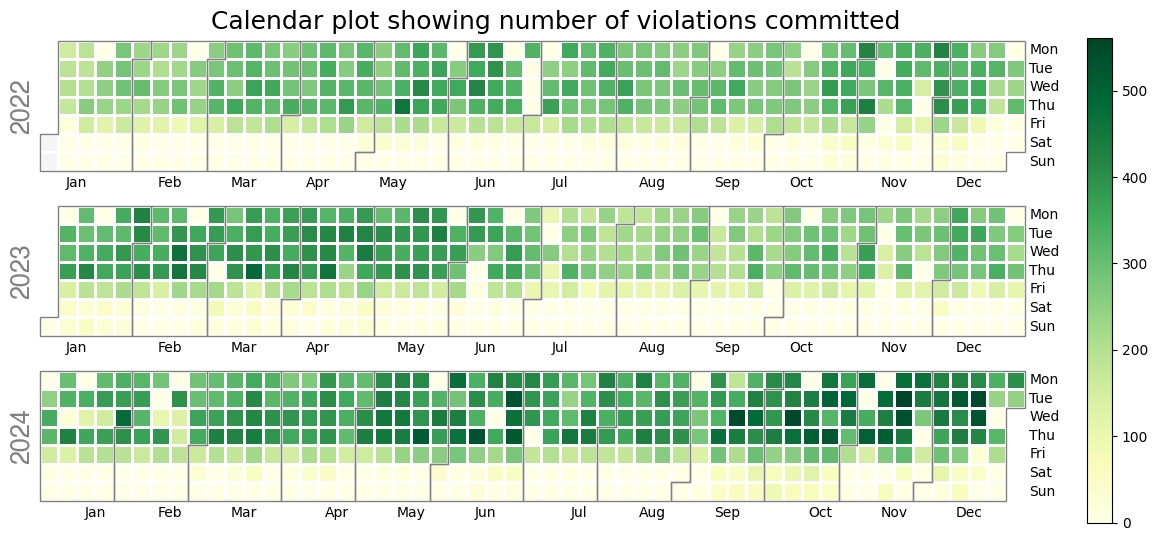

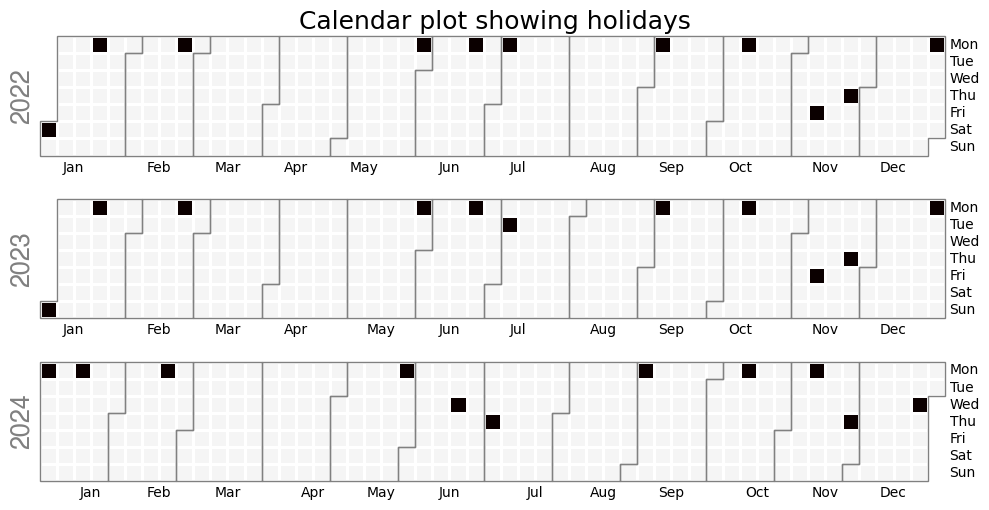

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import calplot
import numpy as np

# Assuming 'restaurant_violations' is your dataframe and 'Date' column exists
data_part3 = data_health.groupby('Date').size()

# List of holidays
holidays = ['2022-01-01', '2022-01-17', '2022-02-21', '2022-05-30', '2022-06-20', '2022-07-04', '2022-09-05', '2022-10-10', 
            '2022-11-11', '2022-11-24', '2022-12-26', '2023-01-01', '2023-01-16', '2023-02-20', '2023-05-29', '2023-06-19', 
            '2023-07-04', '2023-09-04', '2023-10-09', '2023-11-10', '2023-11-23', '2023-12-25', '2024-01-01', '2024-01-15', 
            '2024-02-19', '2024-05-27', '2024-06-19', '2024-07-04', '2024-09-02', '2024-10-14', '2024-11-11', '2024-11-28', '2024-12-25']
holidays = pd.to_datetime(holidays)



# Create the calendar plot for data_part3
fig1, ax1 = calplot.calplot(
    data_part3, 
    suptitle='Calendar plot showing number of violations committed', 
    suptitle_kws={'fontsize': 18}, 

    cmap='YlGn', 
    colorbar=True, 
    yearlabels=True,
    yearlabel_kws={'fontsize': 18}
)

# Create the calendar plot for holidays
holiday_series = pd.Series(1, index=holidays)  
fig2, ax2 = calplot.calplot(
    holiday_series, 
    suptitle='Calendar plot showing holidays', 
    suptitle_kws={'fontsize': 18}, 
    cmap='hot', 
    colorbar=False, 
    yearlabels=True,
    yearlabel_kws={'fontsize': 18}
)

# Show the plots
plt.show()

**Calendar Plot** 

The calender plot of daily patterns show that most violations happens (or are logged) on weekdays most likely due to the normal workweek. This aligns with the holidays for each year where we can see a drop in violations as people are off work these days.


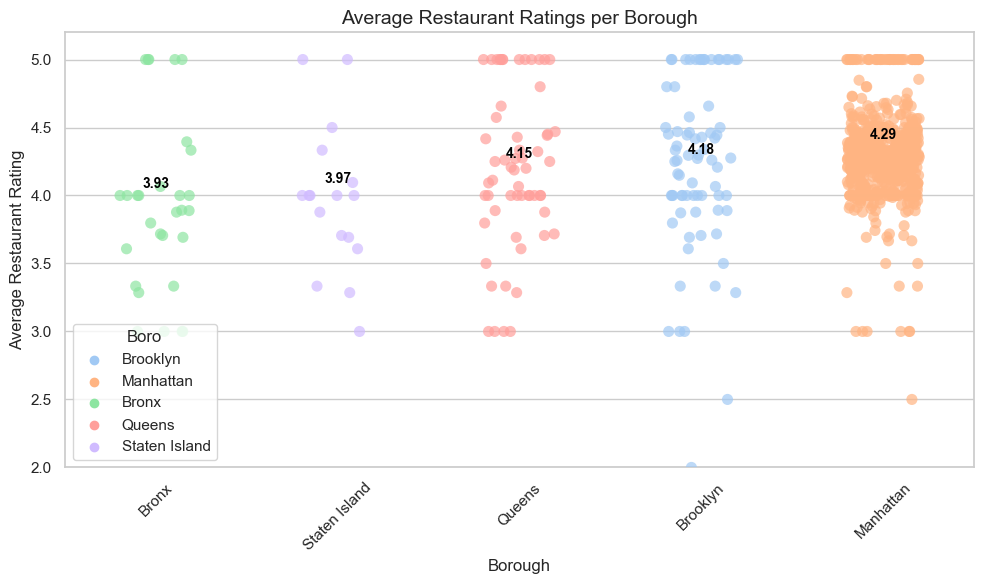

In [12]:
# -------- Visualization of the average restaurant rating per borough -------- #
def scatter_rating_boro(data):
    data = data.copy()
    data = pd.DataFrame(data)

    # Ensure 'avg_rating' is numeric and drop non-numeric values
    data['avg_rating'] = pd.to_numeric(data['avg_rating'], errors='coerce')
    data = data.dropna(subset=['avg_rating'])

    rc('font', family='Arial')

    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")

    boro_order = data.groupby('Boro')['avg_rating'].mean().sort_values().index

    sns.stripplot(
        data=data,
        x='Boro',
        y='avg_rating',
        order=boro_order,
        hue='Boro',
        palette=sns.color_palette("pastel", n_colors=len(data['Boro'].unique())),
        jitter=0.2,
        alpha=0.7,
        size=8
    )

    avg_ratings = data.groupby('Boro')['avg_rating'].mean().round(2)
    for i, boro in enumerate(boro_order):
        plt.text(i, avg_ratings[boro] + 0.1, f'{avg_ratings[boro]:.2f}',
                 ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

    plt.title('Average Restaurant Ratings per Borough', fontsize=14)
    plt.xlabel('Borough')
    plt.ylabel('Average Restaurant Rating')
    plt.ylim(2, 5.2)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# -------------- Execution -------------- #
scatter_rating_boro(merged_data)


**Scatterplot for average ratings**

This plot helps identify how restaurant ratings vary across boroughs, revealing that Manhattan (4.29) and Brooklyn (4.18) tend to have higher-rated establishments, while the Bronx and Staten Island have lower averages (3.93 and 3.97), which may reflect differences in restaurant density, customer expectations, or service quality.

In [13]:
def plot_polar_ratings(data):
    
    fig = make_subplots(
        rows=1, cols=5,
        specs=[[{'type': 'polar'}]*5],
        subplot_titles=["Rating 1", "Rating 2", "Rating 3", "Rating 4", "Rating 5"],
        horizontal_spacing=0.1
    )

    
    months = ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December']

    
    color_map = {
        1: '#EF553B',
        2: '#FFA15A',
        3: '#00CC96',
        4: '#636EFA',
        5: '#AB63FA'
    }

    overall_month_counts = data['Month'].value_counts().reindex(range(1, 13), fill_value=0)
    overall_month_proportions = overall_month_counts / overall_month_counts.sum()

    
    for rating in range(1, 6):
        rating_data = data[data['Restaurant rating'] == rating]
        rating_month_counts = rating_data['Month'].value_counts().reindex(range(1, 13), fill_value=0)
        rating_month_proportions = rating_month_counts / rating_month_counts.sum()

        normalized_counts = rating_month_proportions / overall_month_proportions

        fig.add_trace(go.Barpolar(
            r=normalized_counts.values,
            theta=months,
            base=[0]*12,
            opacity=0.5,
            name=f"Rating {rating}",
            marker_color=color_map.get(rating, '#CCCCCC'),
            marker_line_color="black",
            marker_line_width=1,
            legendgroup=f"Rating {rating}",
            showlegend=True
        ), row=1, col=rating)

    fig.update_layout(
        title='Restaurant Ratings Distribution by Month',
        polar=dict(
            radialaxis=dict(visible=True),
            angularaxis=dict(direction="clockwise", period=12)
        ),
        showlegend=True,
        legend=dict(
            x=1.05,
            y=0.5,
            xanchor='left',
            yanchor='middle',
            orientation='v'
        ),
        width=1300, 
        height=500,
    )
    fig.show()

plot_polar_ratings(data_review)

**Polar plot of customer rating**

Polar plot showing the customar rating by months. Shows that the rating 1 is mostly receive in november and december but does not show anything about the rest of the grades. As there are relatively few 1 ratings this is not as showing.

**Overall insight**

These plots reflect our initial exploration of the data as we searched for a compelling angle and narrative to pursue. We created numerous visualizations, examining trends over time, investigating specific violations for any noteworthy patterns, and analyzing data across calendar years to uncover potential insights. However, we ultimately found that these plots did not support the narrative we aimed to develop around where to eat. While they reveal some trends, none were directly relevant to our intended story. The final plot—showing the average of ratings—was the most aligned with our narrative, but the information it presents could just as effectively be conveyed in a simple table.


## Visualizations and data analysis

In [14]:
# -------------- Calculate average restaurant rating -------------- #
merged_data['avg_rating'] = pd.to_numeric(merged_data['avg_rating'], errors='coerce')

# Group by borough and calculate the mean of avg_rating
borough_avg_rating = merged_data.groupby('Boro')['avg_rating'].mean().reset_index().round(2)
borough_avg_rating

,Boro,avg_rating
0,Bronx,3.93
1,Brooklyn,4.18
2,Manhattan,4.29
3,Queens,4.15
4,Staten Island,3.97


### Plot showing restaurant rating vs health score

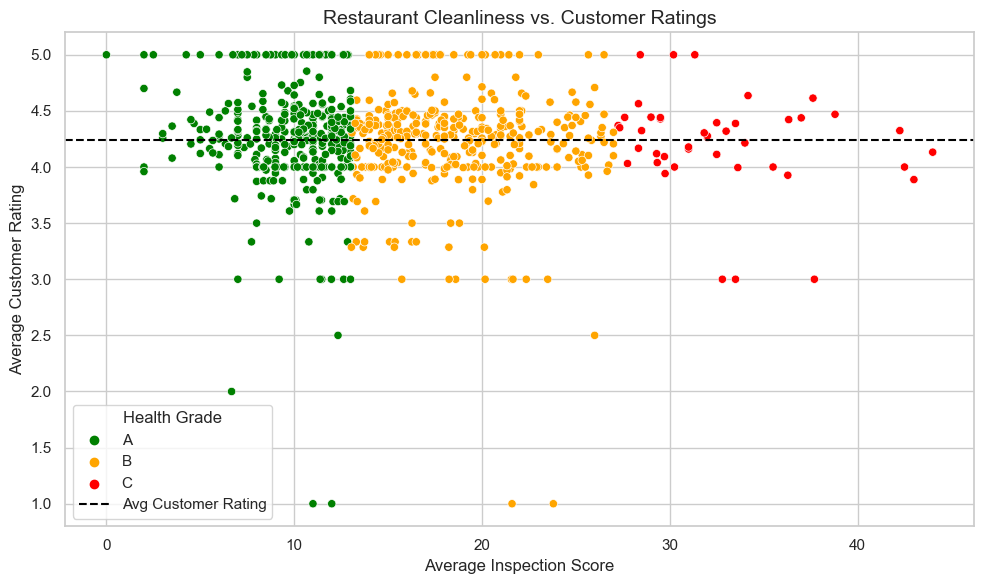

In [15]:
# -------- Visulatization of the average restaurant rating vs average score -------- #

def plot_analysis(merged):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set(style="whitegrid")

    # Plot 1: Score vs Rating
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=merged,
        x='Score',
        y='avg_rating',
        hue='Grade',
        hue_order=['A', 'B', 'C'],  # Correct order
        palette={'A': 'green', 'B': 'orange', 'C': 'red'},
        alpha=1,
        edgecolor='w'
    )

    plt.axhline(merged['avg_rating'].mean(), linestyle='--', color='black', label='Avg Customer Rating')
    plt.title('Restaurant Cleanliness vs. Customer Ratings', fontsize=14)
    plt.xlabel('Average Inspection Score')
    plt.ylabel('Average Customer Rating')
    plt.legend(title='Health Grade', loc='lower left')
    plt.tight_layout()
    plt.savefig('score_vs_rating.png')
    plt.show()

    return merged


# -------------- Execution -------------- #
result = plot_analysis(merged_data)


**Scatterplot showing restaurant rating vs health score**

The scatterplot shows how restaurant ratings and health scores are related. Most ratings are high (above 3.5) regardless of the inspection score

### Bar plots showing different basic stats

In [16]:
# -------------- Data analysis for barplots -------------- #

# Find and count the top 10 of cuisine descriptions types
type = data_health[['Camis', 'Cuisine Description']].drop_duplicates().groupby('Cuisine Description')['Camis'].count()
type = type.sort_values(ascending=False).head(10)


# Number of restaurants per borough
borough_counts = data_health[['Camis', 'Boro']].drop_duplicates().groupby('Boro')['Camis'].count()
borough_counts = borough_counts.sort_values(ascending=False)


# Find and count the top 10 of violation codes and add descriptions
vc_counts = data_health['Violation Code'].value_counts().head(10).reset_index()
vc_counts.columns = ['Violation Code', 'Count']
violation_descriptions = {
    '10F': 'Unsanitary or inaccessible surface.',
    '08A': 'Pest-conducive conditions present.',
    '06D': 'Unsanitized food surface.',
    '02G': 'TCS food held above safe temperature.',
    '10B': 'Improper waste or drainage system.',
    '04L': 'Mice or signs of mice present.',
    '06C': 'Contamination risk to food/equipment.',
    '02B': 'Hot food below 140ºF.',
    '04N': 'FRSA flies or pests present.',
    '04A': 'No certified food supervisor.'
}
vc_counts['Description'] = vc_counts['Violation Code'].map(violation_descriptions)


# Find the health grades distribution per borough
data_grade_bar = pd.DataFrame(merged_data)
borough_counts = merged_data[['Restaurant', 'Boro']].drop_duplicates().groupby('Boro')['Restaurant'].count()
borough_counts = borough_counts.sort_values(ascending=False)
grade_counts = data_grade_bar.groupby(['Boro', 'Grade']).size().unstack(fill_value=0)[['A', 'B', 'C']]
grade_counts = grade_counts.div(borough_counts, axis=0)


In [17]:

# ---------------- Barplots ----------------- #

# Barplots for Restaurant count, Most occurring cuisines, and Most occurring violation codes
fixed_borough_order = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]

borough_counts = borough_counts.reindex(fixed_borough_order).fillna(0)

data_1 = {
    "Restaurant count": {"x": borough_counts.index, "y": borough_counts.values, "x_title": "Borough", "y_title": "Number of Restaurants"},
    "Most occurring cuisines": {"x": type.index, "y": type.values, "x_title": "Types of cuisine", "y_title": "Number of Restaurants"},
    "Most occuring violation codes": {"x": vc_counts['Violation Code'], "y": vc_counts['Count'], "x_title": "Violation Code", "y_title": "Count"},
}

fig = go.Figure()

for i, (name, values) in enumerate(data_1.items()):
    if name == "Most occuring violation codes":
        fig.add_trace(go.Bar(
            x=vc_counts['Violation Code'],
            y=vc_counts['Count'],
            name="Most occuring violation codes",
            visible=False,
            showlegend=False,
            hovertemplate='%{x}: %{customdata[0]}<br>Count: %{y:,}<extra></extra>',
            customdata=vc_counts[['Description']].values
        ))
    else:
        fig.add_trace(go.Bar(
            x=values["x"],
            y=values["y"],
            name=name,
            visible=(i == 0),
            showlegend=False,
            hoverinfo='x+y',
        ))

# -------- Dropdown Menu Buttons --------
buttons_main = []


for i, (name, values) in enumerate(data_1.items()):
    vis = [False] * len(fig.data)
    vis[i] = True
    buttons_main.append(dict(
        label=name,
        method="update",
        args=[
            {"visible": vis},
            {
                "title": f"{name}",
                "xaxis.title.text": values["x_title"],
                "yaxis.title.text": values["y_title"],
                "yaxis.tickformat": "d"
            }
        ]
    ))

# -------- Final Layout --------
fig.update_layout(
    font=dict(
        family="Arial",
        size=12,
        color="black"
    ),
    updatemenus=[
        dict(
            buttons=buttons_main,
            direction="down",
            showactive=True,
            x=1.0,
            xanchor="right",
            y=1.2,
            yanchor="top",
            bgcolor="lightgray"
        )
    ],
    title="Restaurant count",
    xaxis_title=data_1["Restaurant count"]["x_title"],
    yaxis_title=data_1["Restaurant count"]["y_title"],
    plot_bgcolor='white',
    showlegend=False,
    barmode="group"
)

fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='lightgrey',
    gridcolor='lightgrey'
)

fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='lightgrey',
    gridcolor='lightgrey'
)

fig.show()

#Export to HTML
fig.write_html("barplots.html")


**Bar Plots**

The bar plots give a basic overview of the structure and cleanliness of New York City’s restaurant scene. There are three different plots, each showing a different aspect of the data.

1. **Restaurant count by borough**  
This plot shows how many restaurants are in each borough. Manhattan has the most with 7,637 restaurants, followed by Brooklyn (5,660), Queens (4,769), the Bronx (1,753), and Staten Island (803). The numbers reflect population size and how central or tourist-heavy each borough is.

2. **Top 10 most common cuisines**  
This plot displays the most frequently seen cuisine types in NYC. American cuisine is by far the most common with 4,539 restaurants. Chinese (2,070) and Coffee/Tea (1,965) come next. Other common types include Pizza, Mexican, and Japanese.

3. **Top 10 most common violation codes**  
Here we see which health violations occur most often. The most frequent is Code 10F (unsanitary or inaccessible surfaces) with 32,818 cases. Next is Code 08A (conditions that attract pests) with 23,588. Other violations in the top 10 relate to cold storage, plumbing, and food contact surfaces, with counts between 1,500 and 5,000.


These plots help lay the groundwork for understanding the patterns in restaurant presence, cuisine type, hygiene issues, and inspection outcomes across the city.




### Rating and health grade distribution

In [18]:
# ---------------- Barplots ----------------- #

# Barplots for grade distribution and rating distribution

def merged_data_with_all_reviews(health_df, review_df):
    health_summary = health_df[['Restaurant', 'Boro', 'Cuisine Description', 'Grade']].drop_duplicates()

    merged = pd.merge(health_summary, review_df, on='Restaurant', how='inner')

    return merged

merged_review = merged_data_with_all_reviews(data_grade, data_review)
merged_review['Restaurant rating'] = pd.to_numeric(merged_review['Restaurant rating'], errors='coerce').astype('Int64')

rating_counts = (
    merged_review
    .dropna(subset=['Restaurant rating'])
    .groupby('Boro')['Restaurant rating']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
rating_counts

fixed_borough_order = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]

# Reindex to fixed borough order
grade_counts = grade_counts.reindex(fixed_borough_order).fillna(0)
rating_counts = rating_counts.reindex(fixed_borough_order).fillna(0)

# Create subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Health Grade Distribution", "Rating Distribution"),
    shared_yaxes=True,
    horizontal_spacing=0.07,
)

# Health Grade Colors
grade_colors = {'A': 'green', 'B': 'orange', 'C': 'red'}
for grade in ['C', 'B', 'A']:
    fig.add_trace(
        go.Bar(
            x=grade_counts.index,
            y=grade_counts[grade],
            name=f"Health grade {grade}",
            marker_color=grade_colors[grade],
            hovertemplate='%{x}<br>Health grade ' + grade + ': %{y:.1%}<extra></extra>'
        ),
        row=1, col=1
    )

# Rating Colors
rating_colors = {
    1: 'red',
    2: '#ff7f0e',
    3: 'orange',
    4: '#1f77b4',
    5: 'green',
}

for rating in [1, 2, 3, 4, 5]:
    fig.add_trace(
        go.Bar(
            x=rating_counts.index,
            y=rating_counts[rating],
            name=f"Rating {rating}",
            marker_color=rating_colors[rating],
            hovertemplate=f'%{{x}}<br>Rating {rating}: %{{y:.1%}}<extra></extra>'
        ),
        row=1, col=2
    )

# Layout and style improvements
fig.update_layout(
    title=dict(
        text="Distributions by borough",
        x=0.5,
        xanchor='center',
        font=dict(size=20)
    ),
    font=dict(
        family="Arial",
        size=14,
        color="black"
    ),
    plot_bgcolor='white',
    barmode="group",
    legend=dict(
        orientation="v",
        x=1.05,
        y=1,
        bordercolor="lightgrey",
        borderwidth=1
    ),
    margin=dict(l=60, r=150, t=80, b=60),
    width=1200  # Make the figure wider
)

fig.update_xaxes(
    title_text="Borough",
    tickangle=0,
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='lightgrey',
    gridcolor='lightgrey'
)

fig.update_yaxes(
    title_text="Proportion",
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='lightgrey',
    gridcolor='lightgrey',
    tickformat=".0%"
)

fig.show()

# Export to HTML
fig.write_html("barplots_grade_rating_distribution.html")


**Distributions by borough**
These two bar plots show the distribution of health inspection grades and customer ratings across the five New York City boroughs: Manhattan, Brooklyn, Queens, Bronx, and Staten Island. The left plot represents the proportion of restaurants receiving each health grade (A, B, or C), and the right plot shows the proportion of restaurants receiving each customer rating (from 1 to 5 stars).

1. **Health Grade Distribution**
Across all boroughs, the most common grades are A and B, while C grades are significantly less frequent.

- Manhattan and Staten Island have the highest proportions of grade A restaurants, both around or slightly above 45%.
- Bronx stands out with the highest proportion of B grades, close to 50%, and slightly lower A grades compared to other boroughs.
- Queens and Brooklyn show a relatively balanced distribution between grades A and B, with a moderate share of C grades.
- Queens has the highest proportion of grade C establishments, though it still remains under 15%.

2. **Rating Distribution**
Customer ratings generally follow a positive trend across all boroughs, with ratings of 4 and 5 being the most common.

-  Manhattan and Brooklyn have the highest proportions of 5-star ratings, both approaching 50%, indicating high customer satisfaction.
- In contrast, Staten Island has the lowest share of 5-star ratings, while it shows a slightly higher distribution in the 3-star and 4-star categories, suggesting a more mixed reception.
- Bronx has a relatively flat rating profile, with similar proportions in ratings 3, 4, and 5, and a slightly higher presence of lower ratings (1 and 2) compared to other boroughs.
- Queens maintains a strong showing in 4- and 5-star ratings, with very few establishments rated below 3.

These distributions suggest that while health inspection performance varies across boroughs, customer satisfaction is generally high, with most ratings falling in the upper range. The boroughs with higher grade A proportions also tend to show stronger customer ratings, though this is not a strict rule.

### Scatterplot showing what to eat

In [19]:
# Ensure 'data_review_clean' is a DataFrame
import pandas as pd
if not isinstance(data_review, pd.DataFrame):
    data_review = pd.DataFrame(data_review)
data_review['Restaurant rating'] = pd.to_numeric(data_review['Restaurant rating'], errors='coerce').astype('Int64')

def merged_data_with_all_reviews(health_df, review_df):
    # Drop duplicates from health_df based on 'Restaurant', 'Boro', and 'Date'
    health_summary = health_df[['Restaurant', 'Boro', 'Cuisine Description', 'Date', 'Grade']].drop_duplicates(subset=['Restaurant', 'Boro', 'Date'])

    # Calculate the average rating for each restaurant in review_df
    avg_ratings = review_df.groupby('Restaurant')['Restaurant rating'].mean().reset_index()
    avg_ratings.rename(columns={'Restaurant rating': 'avg_rating'}, inplace=True)

    # Merge the health data with the average ratings
    merged = pd.merge(health_summary, avg_ratings, on='Restaurant', how='inner')

    return merged

merged_review = merged_data_with_all_reviews(data_grade, data_review)

In [20]:
# Updated cuisine_grade_percentage function to filter Total Inspections > 3
def cuisine_grade_percentage(merged_data, grade, top_n=10):
	data = merged_data.copy()

	# Ensure correct types
	data['Grade'] = data['Grade'].astype(str)
	data['Cuisine Description'] = data['Cuisine Description'].astype(str)

	# Total inspections per cuisine (denominator)
	total_counts = data['Cuisine Description'].value_counts().reset_index()
	total_counts.columns = ['Cuisine', 'Total Inspections']

	# Filter cuisines with Total Inspections > 1
	total_counts = total_counts[total_counts['Total Inspections'] > 4]

	# Grade-specific inspections per cuisine (numerator)
	grade_counts = data[data['Grade'] == grade]['Cuisine Description'].value_counts().reset_index()
	grade_counts.columns = ['Cuisine', 'Count']

	# Merge totals with grade-specific counts
	merged = pd.merge(total_counts, grade_counts, on='Cuisine', how='left').fillna(0)

	# Compute percentage of inspections that got this grade
	merged['Percentage'] = merged['Count'] / merged['Total Inspections']

	# Add grade label
	merged['Grade'] = grade

	# Return top_n by percentage
	return merged.sort_values(by='Percentage', ascending=False).head(top_n)

# Get top 10 cuisines per grade
top_A = cuisine_grade_percentage(merged_review, 'A', top_n=10)
top_B = cuisine_grade_percentage(merged_review, 'B', top_n=10)
top_C = cuisine_grade_percentage(merged_review, 'C', top_n=10)

# Combine all unique top cuisines
top_cuisines = pd.concat([top_A, top_B, top_C])['Cuisine'].unique()
# Combine all grades (A, B, C) for only top cuisines
cuisine_grade_percent = pd.concat([top_A, top_B, top_C])


In [ ]:
def process_cuisine_data(merged_review, cuisine_grade_percent, top_A, top_C):

    # Reduce merged data to relevant columns and ensure numeric ratings
    merged_data_reduced = merged_review[['Cuisine Description', 'avg_rating']].dropna()
    merged_data_reduced['avg_rating'] = pd.to_numeric(merged_data_reduced['avg_rating'], errors='coerce')

    # Count the number of restaurants per cuisine
    cuisine_counts = merged_data_reduced['Cuisine Description'].value_counts().reset_index()
    rating_by_cuisine = merged_data_reduced.groupby('Cuisine Description', as_index=False)['avg_rating'].mean()
    cuisine_counts = pd.merge(cuisine_counts, rating_by_cuisine, on='Cuisine Description', how='left')

    # Filter top cuisines
    top_cuisines = pd.Series(pd.concat([top_A['Cuisine'], top_C['Cuisine']]).unique())
    rating_by_cuisine = cuisine_counts[cuisine_counts['Cuisine Description'].isin(top_cuisines)]
    rating_by_cuisine.rename(columns={'Cuisine Description': 'Cuisine'}, inplace=True)

    # Merge grade percentages and ratings
    cuisine_summary = pd.merge(cuisine_grade_percent, rating_by_cuisine, on='Cuisine', how='outer').sort_values(by='Grade')

    # Pivot grade percentages to columns
    cuisine_wide = cuisine_summary.pivot(index='Cuisine', columns='Grade', values='Percentage').reset_index()
    cuisine_wide.columns.name = None
    cuisine_wide.rename(columns={'A': 'Pct_A', 'B': 'Pct_B', 'C': 'Pct_C'}, inplace=True)

    # Get total inspections
    total_inspections = cuisine_grade_percent[['Cuisine', 'Total Inspections']].drop_duplicates()

    # Final dataset with full outer joins
    cuisine_final = pd.merge(cuisine_wide, rating_by_cuisine, on='Cuisine', how='outer')
    cuisine_final = pd.merge(cuisine_final, total_inspections, on='Cuisine', how='outer')

    # Filter and sort for top cuisines with grade A and grade C
    cuisine_final_A = cuisine_final[cuisine_final['Cuisine'].isin(top_A['Cuisine'])].copy()
    cuisine_final_C = cuisine_final[cuisine_final['Cuisine'].isin(top_C['Cuisine'])].copy()

    cuisine_final_A.sort_values(by='Pct_A', ascending=False, inplace=True)
    cuisine_final_C.sort_values(by='Pct_C', ascending=False, inplace=True)

    # Fill missing values
    cuisine_final_A['avg_rating'] = cuisine_final_A['avg_rating'].fillna(0)
    cuisine_final_C['avg_rating'] = cuisine_final_C['avg_rating'].fillna(0)
    cuisine_final_A['Total Inspections'] = cuisine_final_A['Total Inspections'].fillna(0)
    cuisine_final_C['Total Inspections'] = cuisine_final_C['Total Inspections'].fillna(0)

    return cuisine_final_A, cuisine_final_C


In [22]:
cuisine_final_A, cuisine_final_C = process_cuisine_data(merged_review, cuisine_grade_percent, top_A, top_C)

In [23]:
cuisine_final_A.head()


,Cuisine,Pct_A,Pct_B,Pct_C,count,avg_rating,Total Inspections
20,Soups/Salads/Sandwiches,0.944444,NaN,NaN,18.0,4.197959,18
5,Donuts,0.838485,NaN,NaN,1003.0,3.709724,1003
17,Salads,0.834320,NaN,NaN,169.0,4.340358,169
19,Soul Food,0.833333,NaN,NaN,6.0,4.177083,6
23,Tex-Mex,0.823009,NaN,NaN,339.0,4.069323,339


In [24]:
cuisine_final_C.head()

,Cuisine,Pct_A,Pct_B,Pct_C,count,avg_rating,Total Inspections
6,German,NaN,NaN,0.400000,5.0,4.030588,5
15,Portuguese,NaN,NaN,0.333333,9.0,4.917862,9
7,Greek,NaN,NaN,0.300000,30.0,4.406104,30
26,Vegetarian,NaN,0.285714,0.285714,7.0,4.227895,7
12,Jewish/Kosher,NaN,NaN,0.240000,50.0,3.919937,50


In [25]:
import plotly.express as px
# make y-range similar for both plots
y_min = min(cuisine_final_A['avg_rating'].min(), cuisine_final_C['avg_rating'].min())-0.3
y_max = 5+0.3

# Plot Grade A
fig_a = px.scatter(
    cuisine_final_A,
    x='Pct_A',
    y='avg_rating',
    size='Total Inspections',
    color='Cuisine',
    size_max=60,
    title='Top 10 Cuisines with Highest A Grade Rates — Ratings vs. Health Inspection'
)

# Assign correct customdata and hovertemplate for each trace
for trace in fig_a.data:
    cuisine = trace.name
    subset = cuisine_final_A[cuisine_final_A['Cuisine'] == cuisine]

    trace.customdata = subset[['Cuisine', 'Pct_A', 'avg_rating', 'Total Inspections']].values
    trace.hovertemplate = (
        'Cuisine: %{customdata[0]}<br>' +
        'Percentage of A Grades: %{customdata[1]:.2%}<br>' +
        'Average Customer Rating: %{customdata[2]:.2f}<br>' +
        'Total Inspections: %{customdata[3]:,.0f}<extra></extra>'
    )

# Layout styling
fig_a.update_layout(
    width=945,
    template='plotly_white',
    title_x=0.49,
    xaxis_title='Percentage of A Grades',
    yaxis_title='Average Customer Rating',
    yaxis=dict(range=[y_min, y_max]),
    legend=dict(
    x=1.02,
    y=1,
    xanchor='left',
    yanchor='top'
)
)

# alter x-range so the two plots line up
fig_a.update_xaxes(
    tickformat=".0%",
    dtick=0.03,
    range=[0.75, 0.99]
)

fig_a.show()


# Plot Grade C
import plotly.express as px

# Build the scatter plot
fig_c = px.scatter(
    cuisine_final_C,
    x='Pct_C',
    y='avg_rating',
    size='Total Inspections',
    color='Cuisine',
    size_max=60,
    title='Top 10 Cuisines with Highest C Grade Rates — Ratings vs. Health Inspection'
)

# Assign correct customdata and hovertemplate for each trace
for trace in fig_c.data:
    cuisine = trace.name
    subset = cuisine_final_C[cuisine_final_C['Cuisine'] == cuisine]

    trace.customdata = subset[['Cuisine', 'Pct_C', 'avg_rating', 'Total Inspections']].values
    trace.hovertemplate = (
        'Cuisine: %{customdata[0]}<br>' +
        'Percentage of C Grades: %{customdata[1]:.2%}<br>' +
        'Average Customer Rating: %{customdata[2]:.2f}<br>' +
        'Total Inspections: %{customdata[3]:,.0f}<extra></extra>'
    )

# Layout styling
fig_c.update_layout(
    width=907,
    template='plotly_white',
    title_x=0.5,
    xaxis_title='Percentage of C Grades',
    yaxis_title='Average Customer Rating',
    yaxis=dict(range=[y_min, y_max]),
    legend=dict(
    x=1.02,
    y=1,
    xanchor='left',
    yanchor='top'
)
)
# alter x-range so the two plots line up
fig_c.update_xaxes(
    tickformat=".0%",
    dtick=0.03,
    range=[0.18, 0.42]
)
fig_c.show()

#save both to html
fig_a.write_html("top_cuisines_A.html")
fig_c.write_html("top_cuisines_C.html")


**Scatter plot**

These plots provide an overview and direct comparison between customer ratings and health inspection outcomes for different cuisine types. Each point represents a cuisine, with its position based on the percentage of a specific grade received during health inspections (A or C) and the average customer rating. The size of each bubble reflects the relative prevalence or volume of that cuisine.

1. **Plot for A grade**
It can be seen that most of the cuisine types cluster around 80–85% of 'A' grades and average customer ratings between 3.5 and 4.5. A few cuisines, however, stand out:
Soups/Salads/Sandwiches have a notably high percentage of 'A' grades, reaching above 90%, and a strong customer rating above 4, indicating a well-performing category both in terms of hygiene and customer satisfaction.
Hamburgers have the lowest customer rating among the top 10, at around 3.37, despite a relatively strong A grade rate, suggesting that factors beyond cleanliness may be influencing customer perceptions.
Other cuisines like Tex-Mex, Salads, and Middle Eastern fall within the upper ranges for both metrics, showing well-rounded performance.
Overall, high 'A' grade rates often align with good customer ratings, but exceptions exist where food quality or taste may not match the sanitary score.

2. **Plot for C grade**
Here we see the top 10 cuisines with the highest percentages of 'C' grades, typically indicating poor health inspection results. Most cuisines cluster around 20–25% of 'C' grades and customer ratings between 4 and 4.5, but several interesting outliers emerge:
German and Portuguese cuisines both have relatively high 'C' grade percentages — over 30% — yet diverge significantly in customer ratings. Portuguese cuisine maintains a rating close to 5, while German sits at around 4, suggesting differing levels of customer tolerance for health inspection performance.
Greek, Indian, and Vegetarian cuisines show lower 'C' grade percentages (~20–25%) but still enjoy solid ratings, mostly above 4.2.
Jewish/Kosher and Thai also perform well in terms of customer satisfaction, even with moderate C grade levels.

This plot shows that high rates of low inspection grades do not necessarily correlate with lower customer ratings, highlighting that customers may prioritize factors such as taste, authenticity, and cultural significance over hygiene grades in certain cases.

___

### Polar plots showing monthly distribution of health grades

In [26]:
# --------- Three subplots as polarplots for grade A,B and C -------- #

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'polar'}]*3],
    subplot_titles=["Grade A", "Grade B", "Grade C"],
    horizontal_spacing=0.1
)

grades = ['A', 'B', 'C']
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']
Boro = [boro for boro in fixed_borough_order if boro in data_grade['Boro'].unique()]
max_r = 0.12 

color_map = {
    'Queens': '#636EFA',
    'Manhattan': '#EF553B',
    'Brooklyn': '#00CC96',
    'Bronx': '#AB63FA',
    'Staten Island': '#FFA15A'
}

# Plot each grade in a separate polar subplot
for idx, grade in enumerate(grades, start=1):
    data_used = data_grade[data_grade['Grade'] == grade]
    
    for boro in Boro:
        data_cuisine = data_used[data_used['Boro'] == boro]
        month_counts = data_cuisine['Month'].value_counts().reindex(range(1, 13), fill_value=0)
        normalized_counts = month_counts / month_counts.sum() if month_counts.sum() else month_counts
        max_r = max(max_r, normalized_counts.max())
        
        fig.add_trace(go.Barpolar(
            r=normalized_counts.values,
            theta=months,
            base=[0]*12,
            opacity=0.5,
            name=boro,
            marker_color=color_map.get(boro, '#CCCCCC'),
            marker_line_color="black",
            marker_line_width=1,
            visible='legendonly' if boro == 'Staten Island' else True,
            legendgroup=boro,
            showlegend=(idx == 1),
            hovertemplate='Month: %{theta}<br>Percentage: %{r:.2%}<extra></extra>'
        ), row=1, col=idx)

# Layout adjustments
fig.update_layout(
    title='Cuisine Violation Distribution by Borough for Grades A, B, and C',
    title_x=0.5,
    polar=dict(
        radialaxis=dict(visible=True, range=[0, max_r]),
        angularaxis=dict(direction="clockwise", period=12)
    ),
    polar2=dict(
        radialaxis=dict(visible=True, range=[0, max_r]),
        angularaxis=dict(direction="clockwise", period=12)
    ),
    polar3=dict(
        radialaxis=dict(visible=True, range=[0, max_r]),
        angularaxis=dict(direction="clockwise", period=12)
    ),
    showlegend=True,
    legend=dict(
        x=1.05,
        y=0.5,
        xanchor='left',
        yanchor='middle',
        orientation='v'
    ),
    width=1300, 
    height=500,
)

fig.add_shape(
    type="line",
    x0=0.305, x1=0.305, y0=0, y1=1,
    xref="paper", yref="paper",
    line=dict(color="lightgray", width=2)
)

fig.add_shape(
    type="line",
    x0=0.675, x1=0.675, y0=0, y1=1,
    xref="paper", yref="paper",
    line=dict(color="lightgray", width=2)
)

fig.show()

# ------- Export to HTML ------- #
fig.write_html("polarplots.html")


**Polar plots**

Three plots, one for each grade A, B and C. The plots show how many incident violations there are each month. 
It gives you the option to look at the boroughs in all combinations. 
In the plot for grade A a trend of most violations in months march to may can be observed. For grade B the observations are a more sporatic with most in march, may, october and december. Lastly the plot for grade C shows a trend of more may through october.

As Staten Island is special as it deviates from the otherwise quite symmetrical trends. Grade A plot, high in january, march, april and august. Grade B plot large numbers in march and especially in october. Grade C plot, January, july august and agian high numbers in october.

### Map showing the restaurants

In [27]:
from bokeh.models import HoverTool, CustomJSHover
# -------------- Map showing the restaurant locations, rating, grade -------------- #
def wgs84_to_web_mercator(lat, lon):
    k = 6378137
    x = lon * (k * np.pi / 180.0)
    y = np.log(np.tan((90 + lat) * np.pi / 360.0)) * k
    return x, y

def plot_health_map_with_tiles(df):
    df = df.dropna(subset=['Latitude', 'Longitude', 'Score'])
    df['x'], df['y'] = wgs84_to_web_mercator(df['Latitude'].values, df['Longitude'].values)

    boroughs = [b for b in fixed_borough_order if b in df['Boro'].dropna().unique()]
    grades = sorted(df['Grade'].dropna().unique())
    cuisine = sorted(df['Cuisine Description'].dropna().unique())

    source = ColumnDataSource(df)

    mapper = LinearColorMapper(palette=RdYlGn11, low=df['Score'].min(), high=40)

    p = figure(
        title="NYC Restaurant Health Radar",
        width=800, height=800,
        x_axis_type="mercator", y_axis_type="mercator",
        tools="pan,wheel_zoom,reset"
    )

    p.title.text_font = "arial"
    p.xaxis.axis_label_text_font = "arial"
    p.yaxis.axis_label_text_font = "arial"
    p.legend.label_text_font = "arial"

    tile_url = "https://a.basemaps.cartocdn.com/light_all/{z}/{x}/{y}.png"
    tile_attribution = "© OpenStreetMap contributors, © CARTO"
    tile_source = WMTSTileSource(url=tile_url, attribution=tile_attribution)
    p.add_tile(tile_source)

    p.circle(
        x='x', y='y', size=7,
        source=source,
        color={'field': 'Score', 'transform': mapper},
        line_color=None,
        fill_alpha=0.8,
        legend_field='Grade'
    )


    # Hover feature
    hover = HoverTool(tooltips=[
        ("Restaurant", "@Restaurant"),
        ("Cuisine", "@{Cuisine Description}"),
        ("Score", "@Score"),
        ("Boro", "@Boro"),
        ("Grade", "@Grade"),
        ("Avg Rating", "@avg_rating{custom}"),
    ],
    formatters={
        "@avg_rating": CustomJSHover(code="""
            if (isNaN(value)) {
                return "Not rated";
            } else {
                return value.toString();
            }
        """)
    })
    p.add_tools(hover)

    color_bar = ColorBar(color_mapper=mapper, location=(0, 0), title='Inspection Score')
    color_bar.title_text_font = "arial" 
    p.add_layout(color_bar, 'right')


    # Filter options to show
    boro_select = Select(title="Borough", value="All", options=["All"] + boroughs)
    grade_select = Select(title="Grade", value="All", options=["All"] + grades)
    cuisine_select = Select(title="Cuisine", value="All", options=["All"] + cuisine)

    callback = CustomJS(args=dict(
        source=source,
        original_source=ColumnDataSource(df),
        boro=boro_select, grade=grade_select, cuisine=cuisine_select
    ), code="""
        const data = original_source.data;
        const b = boro.value;
        const g = grade.value;
        const c = cuisine.value;
        const new_data = {x: [], y: [], Score: [], Restaurant: [], Grade: [], Boro: [], 'Cuisine Description': [], avg_rating: []};
        for (let i = 0; i < data['x'].length; i++) {
            const match_boro = (b === 'All' || data['Boro'][i] === b);
            const match_grade = (g === 'All' || data['Grade'][i] === g);
            const match_cuisine = (c === 'All' || data['Cuisine Description'][i] === c);
            if (match_boro && match_grade && match_cuisine) {
                for (const key in new_data) {
                    new_data[key].push(data[key][i]);
                }
            }
        }
        source.data = new_data;
    """)

    boro_select.js_on_change('value', callback)
    grade_select.js_on_change('value', callback)
    cuisine_select.js_on_change('value', callback)

    return column(row(boro_select, grade_select, cuisine_select), p)


show(plot_health_map_with_tiles(merged_data))

# ------- Export to HTML ------- #
output_file("restaurant_map.html")
save(plot_health_map_with_tiles(merged_data))


/var/folders/mk/0w5j6hcs1js4172_jsztz29w0000gn/T/ipykernel_24475/4053955148.py:38: BokehDeprecationWarning:

'circle() method with size value' was deprecated in Bokeh 3.4.0 and will be removed, use 'scatter(size=...) instead' instead.

/var/folders/mk/0w5j6hcs1js4172_jsztz29w0000gn/T/ipykernel_24475/4053955148.py:38: BokehDeprecationWarning:

'circle() method with size value' was deprecated in Bokeh 3.4.0 and will be removed, use 'scatter(size=...) instead' instead.



'/Users/mathildenielsen/Desktop/02806_SD/restaurant_map.html'

**Map of restaurants**

The map shows all restaurants represented as a dot, the dots colour then represents its score given by the health department. 
The map gives three specification options boroughs, grades and cuisine types. This facilitates the option of narrowing down accordin to ones interests.

---

## Data Analysis

Our data analysis aimed to uncover patterns and contradictions between how restaurants are evaluated officially (via health inspections) and how they are perceived publicly (via customer reviews). We structured the analysis around borough comparisons, violation patterns, cuisine trends, and temporal inspection dynamics.

We began with **bar plots** to examine the basic structure of the dataset. These visualizations revealed that:

- Manhattan leads in restaurant count, followed by Brooklyn and Queens.
- The most frequent cuisines are American, Chinese, and Coffee/Tea, suggesting a preference for fast, familiar options.
- The most frequent violation codes given are 'Unsanitary or inaccessible surface' followed by 'Pest-conducive conditions present.', 'Unsanitized food surface'.

To deepen our understanding of borough-level differences, we also analyzed **distributions of health grades and customer ratings by borough**.

- In terms of health grades, A and B dominate across all boroughs, with Grade A being especially prevalent in Manhattan, Brooklyn and Staten Island. Queens and the Bronx show relatively higher proportions of Grade C restaurants.
- For customer ratings, most boroughs see a strong concentration around 4- and 5-star reviews. Manhattan and Brooklyn lead with the highest proportion of 5-star ratings, while Staten Island exhibits more varied feedback, including higher shares of 3-star and 4-star ratings. Interestingly, despite having more C-grade restaurants, Queens maintains a healthy distribution of 4- and 5-star reviews—suggesting that customers may prioritize other factors over inspection outcomes.

Next, we created **scatter plots** to test the hypothesis that better health scores would correlate with better customer ratings. However, we found almost no relationship between these two variables. Some highly rated restaurants had poor sanitation scores, and some very clean places were rated just average by customers. This was a key insight: customer satisfaction is largely driven by experience (service, taste, ambiance), while inspectors focus on unseen factors like storage temperature or pest control.

We used **polar plots** to explore how health grades vary by month. These showed a distinct seasonal trend:

- A-grades are more common in spring, potentially due to new yearly inspections or restaurants cleaning up after winter.
- C-grades increase in summer, likely related to spoilage risks, heat-related stress in kitchens, or simply more inspections during the busy season.

Finally, we developed an **interactive map** to bring all this information together geographically. Each restaurant is shown with its location, average rating, and health grade. This allows users—especially tourists—to make informed decisions on the go, considering both subjective and objective measures of restaurant quality.

Through this analysis, we learned that relying solely on one type of data—reviews or inspections—can be misleading. By combining both, we present a fuller and more accurate picture of NYC’s dining scene.

We did not apply machine learning in this project. The focus was on robust data integration, statistical analysis, and compelling visual storytelling through interactive and static plots.

That said, there are clear opportunities for future machine learning applications, such as:

- Predicting inspection outcomes based on review sentiment or keywords.
- Clustering restaurants by risk level or customer satisfaction profile.
- Recommender systems that balance food quality and hygiene.

For the current scope, our aim was interpretability and transparency—making the data understandable to any user without needing technical expertise.

___

## Genre



To tell our story effectively, we adopted a magazine-style layout. This approach let us guide readers through the data in a structured way while still allowing them to interact and explore different aspects on their own.

We incorporated key tools from visual narrative theory. Descriptions were used throughout the article to provide a helpful commentary on each chart or plot. We used color highlighting to differentiate between high and low grades or ratings, making patterns easier to spot at a glance. The interactive map allowed users to filter and explore data based on geography, which was especially useful for tourists.

From a structural standpoint, we started with broad overviews and moved into more detailed analysis. This included borough-level comparisons, monthly trends, and correlations between grades and ratings. Our map at the end served as both a summary and a tool for discovery, where users could zoom into neighborhoods and see real restaurant-level data.

---

## Visualizations



**Overview of visualizations**

We used a range of visualizations to highlight different aspects of the data and to tell a coherent, data-driven story about restaurant hygiene and customer experience in New York City.

Scatter plots allowed us to explore the relationship between customer review ratings and official inspection scores. While we expected some correlation, the plots revealed almost none, highlighting a disconnect between customer perception and sanitary conditions.

Bar charts were used to show counts and distributions — the number of restaurants in each borough, the most common cuisine types, the most frequent health violation codes and health grade distributions. These plots provided a clear overview of the structural and regulatory landscape of NYC’s food scene.

Polar plots helped uncover seasonal patterns by showing how the proportion of restaurants receiving each health grade changed throughout the year. For instance, we observed that A grades were more common in spring, while C grades spiked in summer—suggesting seasonal influences on hygiene.


To bring all the information together geographically, we built an interactive map. Each restaurant is represented by a dot, colored according to its health grade and annotated with its average rating, cuisine type, and location. This allows users to explore specific areas and identify high-performing restaurants both in terms of cleanliness and public perception.

**Desicions**

For visual consistency, we applied a clear color scheme across all figures: green for grade A, orange for grade B, and red for grade C. These choices align with intuitive interpretations—green signals good hygiene, red warns of poor conditions. Additionally, we standardized the order of boroughs across all visualizations to make comparisons easier and ensure a smooth reading experience.



**Tools**

From Segel & Heer's Figure 7, we utilized the following tools:

- **Zoom and Filter**: Readers can narrow their focus via boroughs and types of violations.
- **Annotations**: Charts and maps include explanations and legends that interpret complex visuals.
- **Multiple visual types**: We utalize calendar heatmaps, scatterplots, bar charts, and maps for varied engagement.
---


## Discussion

We successfully merged and cleaned two fundamentally different datasets—restaurant hygiene inspection results and customer review sentiments. Despite the challenges involved in aligning data from such distinct sources, the end result is a cohesive and informative tool. The visualizations we've created not only illustrate trends and relationships but also tell a story that is both engaging and practically useful. By combining review analysis with hygiene data, we are highlighting an intersection that is often neglected by conventional dining guides. Yet, this intersection is highly relevant—particularly for travelers or health-conscious diners who want to make informed choices and avoid potential food safety issues.

The interactive nature of the visualizations plays a key role in enhancing user engagement. Readers aren’t just passive consumers of information; they can actively explore the data, uncovering insights based on their own interests or concerns. This interactivity transforms the reading experience into one that is more satisfying and captivating. In particular, the interactive map stands out as an effective and approachable visualization. It empowers users to see which dining options align with both hygiene and review data, all while considering their geographical context. This supports our goal of creating a true guide-like experience, where the narrative and data combine to inform real-world decisions.

That said, there are clear opportunities for further enhancement. If more up-to-date review data were available, the analysis could offer a more current and precise reflection of customer experiences. Additionally, a broader dataset would allow us to assign reviews to a greater number of establishments, improving the comprehensiveness and reliability of the tool. Integrating sentiment analysis of written reviews, rather than relying solely on ratings, represents another promising next step. This would add qualitative depth to our insights and help capture nuances that numeric ratings often miss.

We also considered enhancing the map with filters for inspection month, which could allow users to explore hygiene trends over time or focus on recent inspections. However, we ultimately decided against this for now, as adding too many layers might overwhelm the visual simplicity and usability that make the map effective. Still, this feature could be worth revisiting if implemented with careful design.

---

## Contributions


All group members contributed to the overall project, but each had areas of focus. Maria led the data processing, was responsible for building the interactive map adn helped with writing. Mathilde created the polar plots, supported development of the map and did the website setup. Gertrud handled most of the writing, developed the bar chart visualizations and cuisine scatterplot.

Everyone reviewed and contributed to all parts of the analysis to ensure a shared understanding and a consistent voice throughout, and had all a share in everything as we often shared our work and improved each others work.


## References

[1] https://a816-health.nyc.gov/ABCEatsRestaurants/#!/faq <br> 
[2] https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data <br>
[3] https://www.kaggle.com/datasets/rayhan32/trip-advisor-newyork-city-restaurants-dataset-10k 